In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [4]:
df = pd.read_csv('CarPrice_Assignment.csv')

In [5]:
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [6]:
df.shape

(205, 26)

In [7]:
df.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [8]:
colsDrop = ["symboling", "carheight", "stroke", "compressionratio", "peakrpm", "CarName"]
df.drop(columns=colsDrop, axis=1, inplace=True)

In [9]:
num_col = df.select_dtypes(exclude="object").columns
num_col

Index(['car_ID', 'wheelbase', 'carlength', 'carwidth', 'curbweight',
       'enginesize', 'boreratio', 'horsepower', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [10]:
cat_col = df.select_dtypes(include="object").columns
cat_col

Index(['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel',
       'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem'],
      dtype='object')

In [11]:
df[cat_col].nunique()

,0
fueltype,2
aspiration,2
doornumber,2
carbody,5
drivewheel,3
enginelocation,2
enginetype,7
cylindernumber,7
fuelsystem,8


In [12]:
df[cat_col].head()

,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,enginetype,cylindernumber,fuelsystem
0,gas,std,two,convertible,rwd,front,dohc,four,mpfi
1,gas,std,two,convertible,rwd,front,dohc,four,mpfi
2,gas,std,two,hatchback,rwd,front,ohcv,six,mpfi
3,gas,std,four,sedan,fwd,front,ohc,four,mpfi
4,gas,std,four,sedan,4wd,front,ohc,five,mpfi


In [13]:
df = pd.get_dummies(columns = ["fueltype", "aspiration", "doornumber", "drivewheel", "enginelocation"], data=df, drop_first=True)
df.head()

,car_ID,carbody,wheelbase,carlength,carwidth,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,...,horsepower,citympg,highwaympg,price,fueltype_gas,aspiration_turbo,doornumber_two,drivewheel_fwd,drivewheel_rwd,enginelocation_rear
0,1,convertible,88.6,168.8,64.1,2548,dohc,four,130,mpfi,...,111,21,27,13495.0,True,False,True,False,True,False
1,2,convertible,88.6,168.8,64.1,2548,dohc,four,130,mpfi,...,111,21,27,16500.0,True,False,True,False,True,False
2,3,hatchback,94.5,171.2,65.5,2823,ohcv,six,152,mpfi,...,154,19,26,16500.0,True,False,True,False,True,False
3,4,sedan,99.8,176.6,66.2,2337,ohc,four,109,mpfi,...,102,24,30,13950.0,True,False,False,True,False,False
4,5,sedan,99.4,176.6,66.4,2824,ohc,five,136,mpfi,...,115,18,22,17450.0,True,False,False,False,False,False


In [14]:
encoder = OrdinalEncoder()
cat_col = df.select_dtypes(include="object").columns
for i in cat_col:
  df[i] = encoder.fit_transform(df[[i]])

In [15]:
X = df.drop(columns="price", axis=1)
y = df["price"]

In [16]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [17]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

## Model 1: Multiple Linear Regression (All Features)

In [18]:
rgsr = LinearRegression()
model = rgsr.fit(x_train_scaled, y_train)

In [19]:
y_pred = model.predict(x_test_scaled)

In [20]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [21]:
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R-squared: {r2}")

Mean Absolute Error: 2290.8656786193465
Mean Squared Error: 10903387.804626904
Root Mean Squared Error: 3302.027832200526
R-squared: 0.8426284824491135


In [22]:
model.score(x_test_scaled, y_test)

0.8426284824491135

Visualiztion

In [23]:
pip install yellowbrick

In [24]:
from yellowbrick.regressor import PredictionError
visualizer = PredictionError(rgsr)

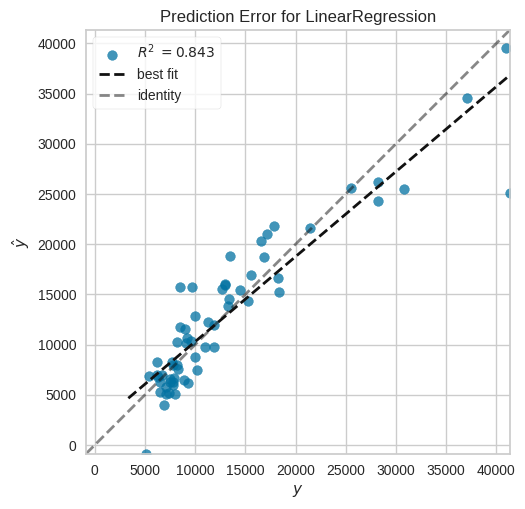

<Axes: title={'center': 'Prediction Error for LinearRegression'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [25]:
visualizer.fit(x_train_scaled, y_train)
visualizer.score(x_test_scaled, y_test)

visualizer.show()

## Feature Selection

In [26]:
from sklearn.feature_selection import SequentialFeatureSelector as sfs

In [69]:
selector = sfs(rgsr, n_features_to_select=5, direction="backward")
selector = selector.fit(x_train_scaled, y_train)

selected_features = list(X.columns[selector.get_support()])
print(selected_features)

['car_ID', 'carwidth', 'enginesize', 'drivewheel_fwd', 'enginelocation_rear']


In [70]:
selector.get_support()

array([ True, False, False, False,  True, False, False, False,  True,
       False, False, False, False, False, False, False, False,  True,
       False,  True])

In [71]:
x_train_selected = x_train[selected_features]
x_test_selected = x_test[selected_features]

In [72]:
scaler_new = StandardScaler()
x_train_sel_scaled = scaler_new.fit_transform(x_train_selected)
x_test_sel_scaled = scaler_new.transform(x_test_selected)

In [73]:
model = rgsr.fit(x_train_sel_scaled, y_train)
y_pred_sfs = model.predict(x_test_sel_scaled)

In [74]:
mae = mean_absolute_error(y_test, y_pred_sfs)
mse = mean_squared_error(y_test, y_pred_sfs)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_sfs)

In [75]:
print(f"Slected Features: {selected_features}")
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R-squared: {r2}")

Slected Features: ['car_ID', 'carwidth', 'enginesize', 'drivewheel_fwd', 'enginelocation_rear']
Mean Absolute Error: 2109.0938788055496
Mean Squared Error: 9877609.315603895
Root Mean Squared Error: 3142.866417079144
R-squared: 0.857433818220084


It should be generalize to make good score.
Use for loop

## Ridge Regression

In [76]:
rgsr = Ridge(alpha=50, max_iter=1000, tol=0.1)
model = rgsr.fit(x_train_scaled, y_train)

In [77]:
model = rgsr.fit(x_train_scaled, y_train)

In [78]:
y_pred = model.predict(x_test_scaled)

In [79]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [80]:
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R-squared: {r2}")

Mean Absolute Error: 2411.7016658262096
Mean Squared Error: 12313453.80146719
Root Mean Squared Error: 3509.053120354149
R-squared: 0.8222766221148885


## Polynomial Regression

In [86]:
from sklearn.preprocessing import PolynomialFeatures

In [81]:
X = df[["enginesize", "horsepower", "curbweight", "highwaympg"]]
Y = df["price"]

In [82]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

In [84]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test) # test data will also be scaled

In [87]:
poly = PolynomialFeatures(degree=2, include_bias=False)
x_train_poly = poly.fit_transform(x_train_scaled)
x_test_poly = poly.fit_transform(x_test_scaled)

In [88]:
rgrs = LinearRegression()
model = rgrs.fit(x_train_poly, y_train)

In [89]:
y_pred = model.predict(x_test_poly)

In [94]:
mae_p = mean_absolute_error(y_test, y_pred)
mse_p = mean_squared_error(y_test, y_pred)
rmse_p = np.sqrt(mse)
r2_p = r2_score(y_test, y_pred)

In [95]:
print(f"Mean Absolute Error: {mae_p}")
print(f"Mean Squared Error: {mse_p}")
print(f"Root Mean Squared Error: {rmse_p}")
print(f"R-squared: {r2_p}")

Mean Absolute Error: 2626.383623094153
Mean Squared Error: 15007480.949179776
Root Mean Squared Error: 3509.053120354149
R-squared: 0.7833930064758203


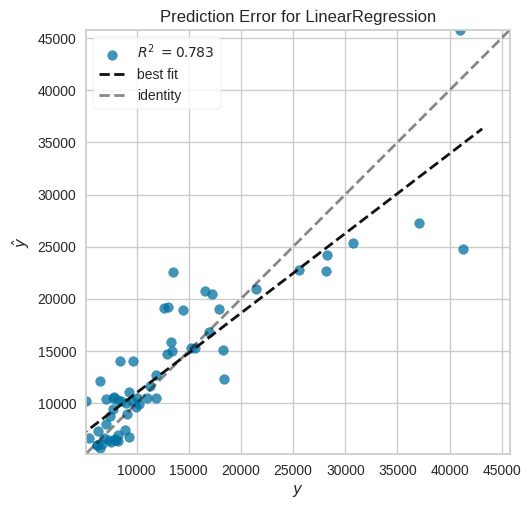

<Axes: title={'center': 'Prediction Error for LinearRegression'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [96]:
poly_visualizer = PredictionError(rgrs)
poly_visualizer.fit(x_train_poly, y_train)
poly_visualizer.score(x_test_poly, y_test)

poly_visualizer.show()

## Polynomial Regression - Visualization

In [128]:
feature_idx = 1
feature_name = X.columns[feature_idx]
x_range = np.linspace(x_test.iloc[:, feature_idx].min(), x_test.iloc[:, feature_idx].max(), 100)
dummy_X = pd.DataFrame(np.tile(x_test.mean().values, (100,1)), columns=x_test.columns)
dummy_X.iloc[:, feature_idx] = x_range

In [129]:
dummy_X_scaled = scaler.transform(dummy_X)
dummy_X_poly = poly.fit_transform(dummy_X_scaled)

In [130]:
curve_preds = model.predict(dummy_X_poly)

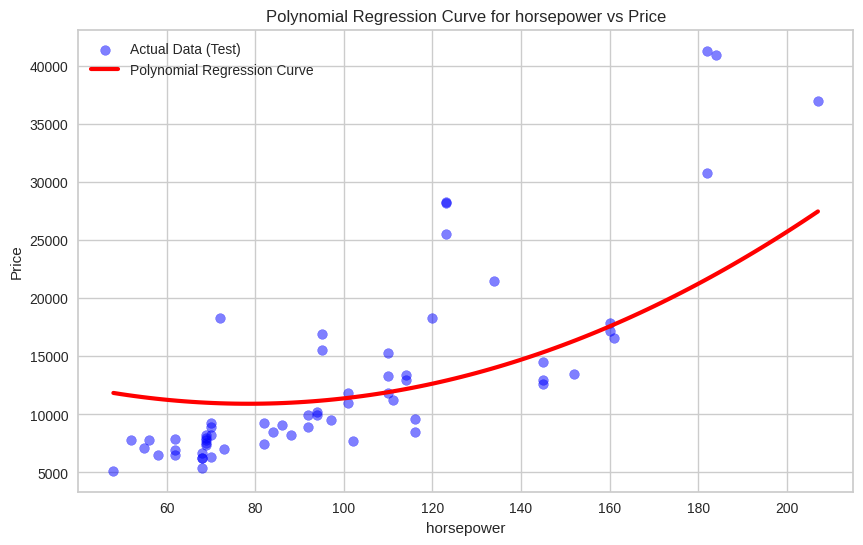

In [131]:
plt.figure(figsize=(10, 6))
plt.scatter(x_test.iloc[:, feature_idx], y_test, alpha=0.5, color='blue', label='Actual Data (Test)')
plt.plot(x_range, curve_preds, color='red', linewidth=3, label='Polynomial Regression Curve')
plt.xlabel(feature_name)
plt.ylabel('Price')
plt.title(f'Polynomial Regression Curve for {feature_name} vs Price')
plt.legend()
plt.show()

In [133]:
x_test.mean().values

array([ 126.66129032,  100.46774194, 2514.80645161,   31.74193548])